In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\crop_recommendation.csv")


In [5]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,102.52,52.93,55.35,29.15,81.95,5.28,214.99,rice
1,108.17,78.37,51.09,31.06,91.83,6.63,123.89,banana
2,29.08,138.16,213.09,13.35,80.59,7.07,84.97,grapes
3,98.95,56.08,66.21,20.86,66.04,5.88,68.27,maize
4,102.89,57.08,66.98,25.27,61.93,7.73,71.83,maize


In [6]:
df.shape

(2250, 8)

In [7]:
df.isna().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [8]:
df.dtypes

N              float64
P              float64
K              float64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2245    False
2246    False
2247    False
2248    False
2249    False
Length: 2250, dtype: bool

In [10]:
df.nunique()

N              1904
P              1949
K              1888
temperature    1286
humidity       1876
ph              267
rainfall       1993
label             9
dtype: int64

In [11]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000,2250.000000
mean,78.000716,82.411413,96.658280,22.092107,68.532484,6.444467,99.103249
std,41.555164,30.705493,71.044906,4.954456,21.676024,0.640104,52.089753
min,21.270000,42.580000,38.310000,12.760000,21.260000,5.270000,38.260000
25%,30.952500,56.730000,50.367500,18.327500,57.837500,5.950000,69.052500
50%,92.300000,72.545000,58.470000,22.680000,74.240000,6.420000,82.085000
75%,110.917500,107.747500,108.020000,25.770000,85.190000,6.927500,99.100000
max,160.930000,149.220000,258.580000,32.180000,97.740000,7.930000,258.230000


In [12]:
label_counts = df['label'].value_counts()
label_counts

label
rice           250
banana         250
grapes         250
maize          250
apple          250
kidneybeans    250
watermelon     250
cotton         250
chickpea       250
Name: count, dtype: int64

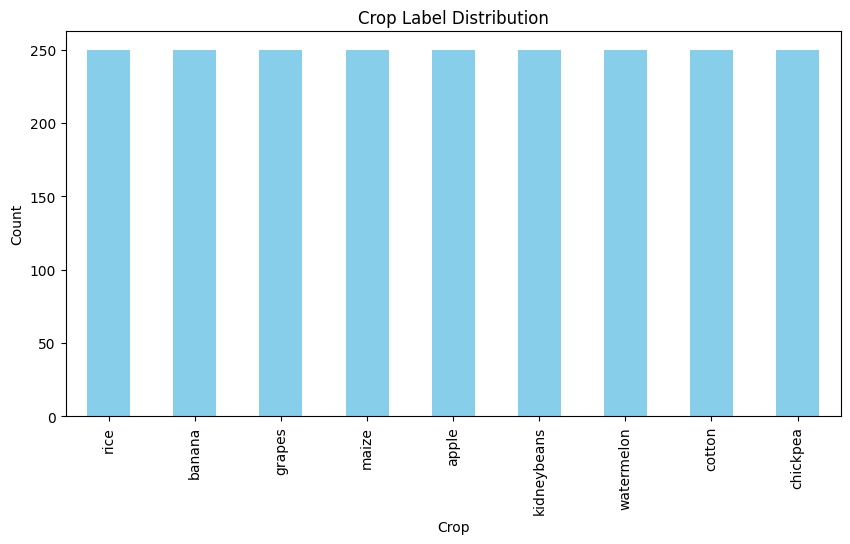

In [13]:
plt.figure(figsize=(10,5))
label_counts.plot(kind='bar', color='skyblue')
plt.title("Crop Label Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

from sklearn.calibration import CalibratedClassifierCV

from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV

from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [19]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,102.52,52.93,55.35,29.15,81.95,5.28,214.99,rice
1,108.17,78.37,51.09,31.06,91.83,6.63,123.89,banana
2,29.08,138.16,213.09,13.35,80.59,7.07,84.97,grapes
3,98.95,56.08,66.21,20.86,66.04,5.88,68.27,maize
4,102.89,57.08,66.98,25.27,61.93,7.73,71.83,maize


In [20]:
X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]


In [22]:
y = df['label']

In [23]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [24]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
677,120.41,110.34,49.81,23.75,87.97,6.97,49.54
1623,27.36,133.89,216.06,14.09,87.66,6.04,83.76
246,98.94,52.93,51.98,29.52,73.86,6.71,222.14
1596,30.96,144.31,241.78,13.32,87.93,6.74,97.15
1091,87.37,51.54,54.84,27.37,80.44,5.42,235.86
...,...,...,...,...,...,...,...
1051,29.76,63.05,51.93,22.94,44.80,6.43,84.24
312,31.94,139.46,210.59,13.15,81.62,6.80,88.16
1270,27.68,124.42,242.48,15.15,84.83,6.07,88.63
401,29.61,146.86,257.62,16.87,75.32,6.45,98.81


In [25]:
X_test

,N,P,K,temperature,humidity,ph,rainfall
2230,29.81,114.36,217.43,15.60,86.06,6.77,77.76
1449,55.27,72.74,86.48,20.62,24.24,6.40,71.39
1341,103.99,75.68,50.00,30.54,79.97,7.11,136.69
1282,108.24,96.98,41.03,24.10,93.02,5.71,40.61
1045,97.29,73.21,52.15,25.65,85.47,7.02,130.24
...,...,...,...,...,...,...,...
670,26.09,111.72,248.83,13.88,77.01,6.20,91.13
2200,28.01,132.83,198.21,14.57,78.90,6.54,97.86
1837,152.46,50.30,51.52,22.92,62.96,6.98,74.11
789,62.64,65.31,103.19,19.98,28.22,6.95,60.34


In [26]:
y_train

677      watermelon
1623         grapes
246            rice
1596         grapes
1091           rice
           ...     
1051    kidneybeans
312          grapes
1270          apple
401          grapes
85         chickpea
Name: label, Length: 1800, dtype: object

In [27]:
y_test

2230        grapes
1449      chickpea
1341        banana
1282    watermelon
1045        banana
           ...    
670         grapes
2200         apple
1837        cotton
789       chickpea
30            rice
Name: label, Length: 450, dtype: object

In [28]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [29]:
X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X_train.columns)

In [30]:
X_train_scaled_df

,N,P,K,temperature,humidity,ph,rainfall
0,1.021873,0.902767,-0.659260,0.334493,0.894145,0.826326,-0.953261
1,-1.218412,1.668391,1.669541,-1.621044,0.879832,-0.637234,-0.294274
2,0.504958,-0.963665,-0.628863,1.502552,0.242656,0.417158,2.370561
3,-1.131738,2.007151,2.029822,-1.776921,0.892298,0.464370,-0.036418
4,0.226397,-1.008855,-0.588800,1.067313,0.546469,-1.612941,2.634773
...,...,...,...,...,...,...,...
1795,-1.160629,-0.634658,-0.629563,0.170519,-1.099107,-0.023483,-0.285030
1796,-1.108143,1.849475,1.592918,-1.811335,0.600952,0.558793,-0.209541
1797,-1.210708,1.360516,2.039628,-1.406462,0.749165,-0.590023,-0.200490
1798,-1.164241,2.090053,2.251706,-1.058271,0.310067,0.007991,-0.004450


In [32]:

# Models dictionary
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=5,
        random_state=42, oob_score=True
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10, min_samples_split=5, random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=7, weights='distance'
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=500, random_state=42, C=1.0
    ),
    "SVM (RBF Kernel)": SVC(
        kernel='rbf', probability=True, C=1.0, gamma='scale', random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200, random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, max_depth=15, random_state=42
    ),
    "Naive Bayes": GaussianNB(),
    "Calibrated Decision Tree": CalibratedClassifierCV(
        estimator=DecisionTreeClassifier(max_depth=10, random_state=42),
        cv=3
    )
}

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

results = []

for name, model in models.items():
    # Scale-sensitive models
    if name in ["KNN", "Logistic Regression", "SVM (RBF Kernel)"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    results.append((name, acc, prec, rec, f1))

    # Print detailed report
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("Classification Report:\n", classification_report(y_test, preds))
    print("-"*70)

# Sort results by accuracy
results_sorted = sorted(results, key=lambda x: x[1], reverse=True)

print("\nSummary of Results:")
print("{:<25} {:<10} {:<10} {:<10} {:<10}".format("Model", "Accuracy", "Precision", "Recall", "F1"))
for r in results_sorted:
    print("{:<25} {:.4f}   {:.4f}   {:.4f}   {:.4f}".format(r[0], r[1], r[2], r[3], r[4]))


Model: Random Forest
Accuracy: 0.9622
Precision: 0.9625
Recall: 0.9622
F1 Score: 0.9622
Confusion Matrix:
 [[40  0  0  0 10  0  0  0  0]
 [ 0 50  0  0  0  0  0  0  0]
 [ 0  0 50  0  0  0  0  0  0]
 [ 0  0  0 50  0  0  0  0  0]
 [ 7  0  0  0 43  0  0  0  0]
 [ 0  0  0  0  0 50  0  0  0]
 [ 0  0  0  0  0  0 50  0  0]
 [ 0  0  0  0  0  0  0 50  0]
 [ 0  0  0  0  0  0  0  0 50]]
Classification Report:
               precision    recall  f1-score   support

       apple       0.85      0.80      0.82        50
      banana       1.00      1.00      1.00        50
    chickpea       1.00      1.00      1.00        50
      cotton       1.00      1.00      1.00        50
      grapes       0.81      0.86      0.83        50
 kidneybeans       1.00      1.00      1.00        50
       maize       1.00      1.00      1.00        50
        rice       1.00      1.00      1.00        50
  watermelon       1.00      1.00      1.00        50

    accuracy                           0.96       450
  

C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Model: AdaBoost
Accuracy: 0.6089
Precision: 0.4863
Recall: 0.6089
F1 Score: 0.5184
Confusion Matrix:
 [[50  0  0  0  0  0  0  0  0]
 [ 0 50  0  0  0  0  0  0  0]
 [31  0  0  0  0 19  0  0  0]
 [ 0  0  0  0  0  0 50  0  0]
 [50  0  0  0  0  0  0  0  0]
 [26  0  0  0  0 24  0  0  0]
 [ 0  0  0  0  0  0 50  0  0]
 [ 0  0  0  0  0  0  0 50  0]
 [ 0  0  0  0  0  0  0  0 50]]
Classification Report:
               precision    recall  f1-score   support

       apple       0.32      1.00      0.48        50
      banana       1.00      1.00      1.00        50
    chickpea       0.00      0.00      0.00        50
      cotton       0.00      0.00      0.00        50
      grapes       0.00      0.00      0.00        50
 kidneybeans       0.56      0.48      0.52        50
       maize       0.50      1.00      0.67        50
        rice       1.00      1.00      1.00        50
  watermelon       1.00      1.00      1.00        50

    accuracy                           0.61       450
   macr

In [34]:
results

[('Random Forest',
  0.9622222222222222,
  0.9624871760560239,
  0.9622222222222222,
  0.9621881915946574),
 ('Decision Tree',
  0.9533333333333334,
  0.9580056246722913,
  0.9533333333333334,
  0.95253110907673),
 ('KNN',
  0.8955555555555555,
  0.8956888344893241,
  0.8955555555555555,
  0.8950412577183756),
 ('Logistic Regression',
  0.9622222222222222,
  0.962962962962963,
  0.9622222222222222,
  0.9621275410749095),
 ('SVM (RBF Kernel)',
  0.9488888888888889,
  0.9489128984927304,
  0.9488888888888889,
  0.9488837772666155),
 ('Gradient Boosting',
  0.9644444444444444,
  0.9644444444444444,
  0.9644444444444444,
  0.9644444444444444),
 ('AdaBoost',
  0.6088888888888889,
  0.48629009694037095,
  0.6088888888888889,
  0.5184319429293716),
 ('Extra Trees', 0.96, 0.96, 0.96, 0.96),
 ('Naive Bayes',
  0.9555555555555556,
  0.9562949759028191,
  0.9555555555555556,
  0.9554495132052888),
 ('Calibrated Decision Tree',
  0.9644444444444444,
  0.9655483405483406,
  0.9644444444444444,
  0.

In [36]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df = results_df.sort_values(by="Accuracy", ascending=False)

# Display
results_df

,Model,Accuracy,Precision,Recall,F1 Score
5,Gradient Boosting,0.964444,0.964444,0.964444,0.964444
9,Calibrated Decision Tree,0.964444,0.965548,0.964444,0.964316
0,Random Forest,0.962222,0.962487,0.962222,0.962188
3,Logistic Regression,0.962222,0.962963,0.962222,0.962128
7,Extra Trees,0.960000,0.960000,0.960000,0.960000
8,Naive Bayes,0.955556,0.956295,0.955556,0.955450
1,Decision Tree,0.953333,0.958006,0.953333,0.952531
4,SVM (RBF Kernel),0.948889,0.948913,0.948889,0.948884
2,KNN,0.895556,0.895689,0.895556,0.895041
6,AdaBoost,0.608889,0.486290,0.608889,0.518432


In [45]:
import pickle as pkl

In [37]:
best_model = RandomForestClassifier(
    n_estimators=300,       
    max_depth=15,           
    min_samples_split=5,    
    random_state=42,
    oob_score=True           
)
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)
acc = accuracy_score(y_test, preds)
print(f"Best Model Accuracy: {acc:.4f}")

Best Model Accuracy: 0.9622


In [38]:
best_model.classes_

array(['apple', 'banana', 'chickpea', 'cotton', 'grapes', 'kidneybeans',
       'maize', 'rice', 'watermelon'], dtype=object)

In [51]:
import pickle

bundle = {
    "model": best_model,
    "feature_cols": ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'],
    "classes": best_model.classes_.tolist()  
}

with open('crop_recommendation_RF.pkl', 'wb') as file:
    pickle.dump(bundle, file)
    print("Bundle saved successfully!")


with open('crop_recommendation_RF.pkl', 'rb') as file:
    b = pickle.load(file)

print("Model:", b["model"])
print("Features:", b["feature_cols"])
print("Classes:", b["classes"])


Bundle saved successfully!
Model: RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators=300,
                       oob_score=True, random_state=42)
Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Classes: ['apple', 'banana', 'chickpea', 'cotton', 'grapes', 'kidneybeans', 'maize', 'rice', 'watermelon']


In [52]:
sample = {'N':90, 'P':40, 'K':40, 'temperature':20, 'humidity':80, 'ph':7, 'rainfall':200}
X = [[sample[c] for c in b["feature_cols"]]]
X

[[90, 40, 40, 20, 80, 7, 200]]

In [53]:
print("Pred:" ,b["model"].predict(X)[0])

Pred: rice


C:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
